In [4]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DATASET_DIRS = {
    "ped": "./learn_dataset_ped_single",
    "vehicle": "./learn_dataset_vehicle_single",
}
META_CSVS = {k: os.path.join(v, "metadata.csv") for k, v in DATASET_DIRS.items()}

# ped専用モデルを上書きしないように分離
MODEL_PATH = "./best_detector_ped_vehicle.pt"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
EPOCHS = 20
LR = 1e-3

# source_index で分割
TRAIN_MAX_IDX = 205
VAL_MAX_IDX = 220

# 評価時の許容誤差（bin単位）
D_TOL = 2
R_TOL = 3

print("DEVICE:", DEVICE)
for k, meta_csv in META_CSVS.items():
    print(f"{k} META_CSV exists:", os.path.exists(meta_csv))

DEVICE: cpu
ped META_CSV exists: True
vehicle META_CSV exists: True


In [5]:
def Radar_setting():
    ###### symbol time & carrier frequency ######
    T_symbol = 5.575 * 1e-6              # symbol duration, with CP time
    T_OFDM = 5.2125 * 1e-6
    f_carrier = 28 * 1e+9
    Tc = 2.545*1e-9                      # sampling time

    ###### tx/rx ######
    N_ant = 16                       # the number of antennas
    # BW = 1.966080e+9                      # chirp bandwidth
    BW = 400*1e+6                    # chirp bandwidth
    BW_sub = BW/N_ant
    N_sample = int(np.floor(T_symbol/Tc))           # the number of samples of single chirp
    rx_sample = 813 + N_sample

    ###### Radar setting ######

    mu = BW_sub/T_symbol * 0.98
    l_speed = 299792458

    lam = l_speed/f_carrier
    env = cyclist_env(f_carrier, N_ant, BW, BW_sub, N_sample, rx_sample, Tc, mu, l_speed)
    return T_symbol,f_carrier,Tc,N_ant,BW,BW_sub,N_sample,rx_sample, mu, l_speed, lam, env

In [6]:
def physical_to_rd_indices(range_m, velocity_mps, N_trans, sym_duration, lam, Tc, range_offset=620, num_range_bins=190):
    c = 299792458.0
    vel_res = lam / (2.0 * sym_duration * N_trans)
    range_res = c * Tc / 2.0

    d_idx = int(np.round(velocity_mps / vel_res)) % N_trans
    r_idx = int(np.round(range_m / range_res - range_offset))

    valid = (0 <= d_idx < N_trans) and (0 <= r_idx < num_range_bins)
    return d_idx, r_idx, valid

In [7]:
def syntax_check(num, idx, y_value, velocity_value, x_pos):
    idx_list = np.zeros(num, dtype=np.int32)
    position, velocity = np.zeros((num, 3)), np.zeros((num, 3))
    i=0
    s = set()
    while i < num:
        # 初期値における距離間隔を保証するための処理
        if idx+10 in s or idx-10 in s or idx in s: continue
        for j in range(-20,20): s.add(idx+j)
        
        idx_list[i] = idx
        position[i] = np.array([x_pos[idx], y_value, 1])
        # v_cy[i] = np.array([np.random.rand(1)[0]*5.56, 0, 0])
        velocity[i] = np.array([velocity_value, 0, 0])
        
        i+=1
    return idx_list, position, velocity

In [8]:
def get_snapshot_data(cy_idx_target, ve_idx_target,x_pos, p_bs, tx, cy_v_value, ve_v_value, num_cy, num_ve, num_rp, sym_duration, N_trans,Tc, env):
    # Cyclistについて
    cy_idx = np.zeros(num_cy, dtype=np.int32)
    p_cy, v_cy = np.zeros((num_cy, 3)), np.zeros((num_cy, 3))
    # 範囲外アクセスを防ぐための処理
    cy_idx, p_cy, v_cy = syntax_check(num_cy, cy_idx_target, 15, cy_v_value, x_pos)
    n_cy = len(p_cy)
    
    # Vehicleについて
    ve_idx = np.zeros(num_ve, dtype=np.int32)
    p_ve, v_ve = np.zeros((num_ve, 3)), np.zeros((num_ve, 3))
    # 範囲外アクセスを防ぐための処理
    ve_idx, p_ve, v_ve = syntax_check(num_ve, ve_idx_target, 7.5, ve_v_value, x_pos)
    n_ve = len(p_ve)

    # ramppostについて
    p_rp, v_rp = np.zeros((num_rp, 3)), np.zeros((num_rp, 3))
    n_rp = len(p_rp)
    
    # csvファイルの読み込み
    cy_idx += 1
    ve_idx += 1

    P_rx_cy, tstemp_rx_cy, phase_cy, P_rx_ve, tstemp_rx_ve, phase_ve, P_rx_rp, tstemp_rx_rp, phase_rp = [], [], [], [], [], [], [], [], []
    # 3番目のデータから読み込み開始（最初の数個はノイズのみのため）
    for i in range(len(cy_idx)):
        df = pd.read_csv("./ped/2.545nano/far/complex-impulse-response-Run{:04d}-Sensor_0_Tx_0_to_Rx_0.csv".format(cy_idx[i]))
        tstemp_rx_cy.append(np.round((df["Time (s)"]/Tc)).values[3:])
        P_rx_cy.append(df["| Total Complex Impulse Response total | (W)"].values[3:])
        phase_cy.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[3:])
    for i in range(len(ve_idx)):
        df = pd.read_csv("./vehicle/2.545nano/far/complex-impulse-response-Run{:04d}-Sensor_0_Tx_0_to_Rx_0.csv".format(ve_idx[i]))
        tstemp_rx_ve.append(np.round((df["Time (s)"].values[3:]/Tc)))
        P_rx_ve.append(df["| Total Complex Impulse Response total | (W)"].values[3:])
        phase_ve.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[3:])
    # 2.545のほうを使う！
    for i in range(2,3):
        df = pd.read_csv("./Ramposts/2.545nano/"+str(i)+"/complex-impulse-response-Run0001-Sensor_0_Tx_0_to_Rx_0.csv")
        tstemp_rx_rp.append(np.round((df["Time (s)"].values[5:]/Tc)))
        P_rx_rp.append(df["| Total Complex Impulse Response total | (W)"].values[5:])
        phase_rp.append(df['Phase( Total Complex Impulse Response total ) (rad)'].values[5:])
    phys_quantities = env.phys_quantities(p_bs, p_cy, v_cy, n_cy, p_ve, v_ve, n_ve, p_rp, v_rp, n_rp)
    #print(phys_quantities["relative_velocity"]["cyclists"])
    real_cy_coordinates = []
    real_vel_coordinates = []
    real_rp_coordinates = []

    for i in range(len(p_cy)):
        real_cy_coordinates.append(np.array([p_cy[i][0], p_cy[i][1]]))
    for i in range(len(p_ve)):
        real_vel_coordinates.append(np.array([p_ve[i][0], p_ve[i][1]]))
    for i in range(len(p_rp)):
        real_rp_coordinates.append(np.array([p_rp[i][0], p_rp[i][1]]))
    
        
    ######### We need some functions here. it is like this. read the csv. this outputs the time stemp and corresponding rx value.
    # P_rx_cy_dB = -114
    #P_rx_cy_dB = -111
    #P_rx_ve_dB = -114
    #P_rx_cy_dB = 0
    #P_rx_ve_dB = 0
    
    P_N_dB = -87.98

    Y = env.rx_multiple(tx, P_rx_cy, tstemp_rx_cy, phase_cy, P_rx_ve, tstemp_rx_ve, phase_ve, P_rx_rp, tstemp_rx_rp, phase_rp, P_N_dB, sym_duration, N_trans)
    
    return Y, phys_quantities, real_cy_coordinates, real_vel_coordinates, real_rp_coordinates

In [9]:
def stevec(N_ant, angle):
    # 入力された角度に対するステアリングベクトルの計算
    resp = (np.arange(N_ant)-N_ant*0.5+0.5).reshape([-1,1])
    resp = np.exp(1j*resp*np.pi*np.sin(angle))
    return np.matrix(resp)

In [10]:
def MUSIC_method_improved(Y, N_ant, num_signals, frame_count):
    '''
    修正前
    Y_music = np.mean(Y, axis=0)
    R_yy = Y_music@np.conjugate(np.transpose(Y_music))
    '''
    # 修正後: 
    # チャープ軸(0)とサンプル軸(2)の両方を「スナップショット」として扱います。
    # (N_trans, N_ant, N_sample) -> (N_ant, N_trans * N_sample) に変形
    # これにより、N_trans(チャープ数)が増えるほど、スナップショット数が増え、
    # 共分散行列 R_yy の推定精度が向上します。
    N_trans, N_ant_data, N_sample = Y.shape
    # データを (アンテナ数 x 全サンプル数) の2次元行列に変形
    Y_music = Y.transpose(1, 0, 2).reshape(N_ant_data, -1)
    
    # 共分散行列の計算
    # (行列サイズは アンテナ数 x アンテナ数 のまま変わらないので計算負荷は軽微です)
    R_yy = (Y_music @ np.conjugate(Y_music.T)) / Y_music.shape[1]
    
    # 1.固有値分解
    eig_val, eig_vec = np.linalg.eig(R_yy)
    
    # 2.固有値をソートして雑音部分空間を取得
    idx = np.abs(eig_val).argsort()[::-1]
    # インデックスによって固有値と固有ベクトルの対応関係を維持しつつソート
    eig_val = eig_val[idx]
    eig_vec = eig_vec[:, idx]
    # 雑音部分空間Uを取得

    # num_signalsを固有値から推定?
    
    # デバッグ用
    num_signals = 5
    
    U = eig_vec[:, num_signals:]
    

    # 3.雑音部分空間とvalごとのステアリングベクトルの内積を計算
    resp = []
    argm = (np.arange(1800)-900)/100
    for val in argm:
        # ステアリングベクトルの計算
        stv = stevec(N_ant, val*np.pi/180)
        # 雑音部分空間との内積
        p = stv.T@U
        # L2ノルムの二乗を計算(pp^H)
        pp = p*np.conjugate(np.transpose(p))
        # A1は行列を1次元配列に変換するメソッド
        # respに逆数を追加
        # 分子は角度推定の上では不要なので省略している
        resp.append(1/(np.abs(pp)**2).A1)
    
    # 4.ピーク検出
    M = np.max(resp)
    
    # デバッグ用
    #MUSIC_method_Debug(eig_val, N_ant, num_signals, resp, argm, M, frame_count)
    
    est_ang = []
    # 三点比較によるピーク検出
    a, b = resp[0][0], resp[1][0]
    for i in range(1,len(argm)-1):
        c = resp[i+1][0]
        #if a < b and b > c and b > 0.2 * M:
        if a < b and b > c and b > 0.00001 * M:
            est_ang.append(argm[i])
        a, b = b, c
    return est_ang

In [11]:
def FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, est_ang, sym_duration, lam, Tc, env):
    # ドップラー処理
    Dopp_dft = dft(N_trans)/np.sqrt(N_trans)
    Y_dft = np.zeros((N_trans, N_ant, rx_sample), dtype=np.complex128)
    for i in range(N_ant):
        Y_dft[:,i,:] = Dopp_dft@Y[:,i,:]
    
    final_objects_all = []
    rd_maps = []

    P_range = np.arange(190)+620

    # FFTによる位置推定処理
    tx_arr = np.array(tx) 
    n_fft = 2**(int(rx_sample + N_sample).bit_length())
    #n_fft = 2048
    
    # 窓関数を掛けずにFFTする
    TX_F_all = fft(tx_arr, n=n_fft, axis=1) 
    Y_F_all = fft(Y_dft, n=n_fft, axis=2)
    
    for i in range(len(est_ang)):
        current_angle = est_ang[i]
        ang_rad = current_angle * np.pi / 180
        
        # ステアリングベクトル (N_ant, 1)
        s_vec = np.array(stevec(N_ant, ang_rad))
        
        # --- 周波数領域でのビームフォーミング ---
        
        # 受信信号の合成: Y_combined = sum(Y * s)
        # s_vec を (1, N_ant, 1) に変形して放送
        # Y_F_all: (N_trans, N_ant, n_fft)
        # 重み付け和をとってアンテナ次元を潰す -> (N_trans, n_fft)
        # 修正前
        w_vec = np.conjugate(s_vec).reshape(1, N_ant, 1)
        Y_F_combined = np.sum(Y_F_all * w_vec, axis=1)
        # 修正後
        w_vec = s_vec.reshape(1, N_ant, 1) 
        Y_F_combined = np.sum(Y_F_all * w_vec, axis=1)

        # 送信信号(レプリカ)の合成: X_combined = sum(X * s*)
        # 元の数式 g = s* s^H X より、Xにかかる重みは s^H (つまり sの共役)
        # TX_F_all: (N_ant, n_fft)
        s_vec_conj_reshape = np.conjugate(s_vec).reshape(N_ant, 1)
        TX_F_combined = np.sum(TX_F_all * s_vec_conj_reshape, axis=0) # -> (n_fft,)

        # --- 相関演算 (Correlation) ---
        # Correlation = IFFT( FFT(Y) * conj(FFT(X)) )
        # Broadcasting: (N_trans, n_fft) * (n_fft,)
        CORR_f = Y_F_combined * np.conjugate(TX_F_combined)
        
        # 時間領域に戻す
        corr_time = ifft(CORR_f, axis=1)

        # --- 必要な範囲を切り出し ---
        rdresp_single = corr_time[:, P_range]

        # --- 結果保存 ---
        rd_maps.append(rdresp_single.copy())
        rd_maps.append(i)

    return rd_maps

In [12]:
def generate_one_sample(sample_id, target_idx):
    T_symbol, f_carrier, Tc, N_ant, BW, BW_sub, N_sample, rx_sample, mu, l_speed, lam, env = Radar_setting()
    N_chirp = 89
    N_trans = N_chirp
    tx = env.tx()

    p_bs = np.array([250, -18, 50])
    x_pos = list(np.arange(-450, -149) / 10)

    if TARGET_KIND == "ped":
        num_cy, num_ve, num_rp = 1, 0, 0
        cy_idx_target = int(target_idx)
        ve_idx_target = 128
        cy_v_value, ve_v_value = 6, 10
        truth_key = "cyclists"
        target_label = 0
    else:
        num_cy, num_ve, num_rp = 0, 1, 0
        cy_idx_target = 150
        ve_idx_target = int(target_idx)
        cy_v_value, ve_v_value = 6, 10
        truth_key = "vehicles"
        target_label = 1

    Y, phys_quantities, real_cy_coordinates, real_vel_coordinates, real_rp_coordinates = get_snapshot_data(
        cy_idx_target, ve_idx_target, x_pos, p_bs, tx,
        cy_v_value, ve_v_value, num_cy, num_ve, num_rp,
        T_symbol, N_trans, Tc, env
    )

    est_ang = MUSIC_method_improved(Y, N_ant, num_cy + num_ve + num_rp, frame_count=sample_id)
    rd_maps = FFT(N_trans, N_ant, rx_sample, Y, tx, N_sample, est_ang, T_symbol, lam, Tc, env)

    true_range = float(np.asarray(phys_quantities["range"][truth_key][0]).reshape(-1)[0])
    true_velocity = float(np.asarray(phys_quantities["relative_velocity"][truth_key][0]).reshape(-1)[0])
    true_angle_deg = float(np.degrees(np.asarray(phys_quantities["angle"][truth_key][0]).reshape(-1)[0]))

    d_idx, r_idx, valid = physical_to_rd_indices(
        true_range, true_velocity, N_trans, T_symbol, lam, Tc
    )

    save_path = os.path.join(OUTPUT_DIR, f"sample_{sample_id:05d}.npz")
    np.savez_compressed(
        save_path,
        rd_maps=np.array(rd_maps[::2], dtype=np.complex64),
        est_ang=np.array(est_ang, dtype=np.float32),
        true_range=np.float32(true_range),
        true_velocity=np.float32(true_velocity),
        true_angle_deg=np.float32(true_angle_deg),
        true_d_idx=np.int32(d_idx),
        true_r_idx=np.int32(r_idx),
        valid=np.int32(valid),
        target_label=np.int32(target_label),
        source_index=np.int32(target_idx),
    )

    return {
        "sample_id": sample_id,
        "file": save_path,
        "target_kind": TARGET_KIND,
        "source_index": target_idx,
        "num_angles": len(est_ang),
        "true_range": true_range,
        "true_velocity": true_velocity,
        "true_angle_deg": true_angle_deg,
        "true_d_idx": d_idx,
        "true_r_idx": r_idx,
        "valid": int(valid),
    }

In [13]:
class SingleTargetDataset(Dataset):
    def __init__(self, meta_df):
        self.meta_df = meta_df.reset_index(drop=True)

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]

        npz_path = row["file"]
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join(".", npz_path))

        rd_complex, used_angle = load_best_angle_rd(npz_path, row["true_angle_deg"])
        x = rd_to_input(rd_complex)

        H, W = rd_complex.shape
        y = make_gaussian_heatmap(
            H, W,
            int(row["true_d_idx"]),
            int(row["true_r_idx"]),
            sigma_d=1.5,
            sigma_r=2.0
        )[None, :, :]

        sample = {
            "x": torch.from_numpy(x).float(),
            "y": torch.from_numpy(y).float(),
            "true_d": torch.tensor(int(row["true_d_idx"]), dtype=torch.long),
            "true_r": torch.tensor(int(row["true_r_idx"]), dtype=torch.long),
            "used_angle": torch.tensor(float(used_angle), dtype=torch.float32),
        }
        return sample

In [29]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels=32, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)

class RadarLightUNet(nn.Module):
    def __init__(self, in_channels=1, fixed_channels=32, dropout=0.1):
        super().__init__()

        self.encoders = nn.ModuleList([
            ConvBlock(in_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
            ConvBlock(fixed_channels, fixed_channels, dropout),
        ])
        self.pools = nn.ModuleList([
            nn.MaxPool2d(2, 2) for _ in range(6)
        ])
        self.bottleneck = ConvBlock(fixed_channels, fixed_channels, dropout)
        self.upsamples = nn.ModuleList([
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
            for _ in range(6)
        ])
        self.decoders = nn.ModuleList([
            ConvBlock(fixed_channels * 2, fixed_channels, dropout)
            for _ in range(6)
        ])
        self.head = nn.Conv2d(fixed_channels, 1, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.upsamples, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        return self.head(x)  # logits

In [30]:
def load_metadata(target_kind, meta_csv):
    df = pd.read_csv(meta_csv)

    # 最低限のフィルタ
    df = df[(df["valid"] == 1) & (df["num_angles"] > 0)].copy()

    # 念のため付与
    df["target_kind"] = target_kind
    return df

df = pd.concat(
    [load_metadata(target_kind, meta_csv) for target_kind, meta_csv in META_CSVS.items()],
    ignore_index=True,
)

train_df = df[df["source_index"] <= TRAIN_MAX_IDX].reset_index(drop=True)
val_df = df[(df["source_index"] > TRAIN_MAX_IDX) & (df["source_index"] <= VAL_MAX_IDX)].reset_index(drop=True)
test_df = df[df["source_index"] > VAL_MAX_IDX].reset_index(drop=True)

ped_val_df = val_df[val_df["target_kind"] == "ped"].reset_index(drop=True)
vehicle_val_df = val_df[val_df["target_kind"] == "vehicle"].reset_index(drop=True)
ped_test_df = test_df[test_df["target_kind"] == "ped"].reset_index(drop=True)
vehicle_test_df = test_df[test_df["target_kind"] == "vehicle"].reset_index(drop=True)

summary_df = pd.DataFrame({
    "train": train_df["target_kind"].value_counts(),
    "val": val_df["target_kind"].value_counts(),
    "test": test_df["target_kind"].value_counts(),
}).reindex(["ped", "vehicle"]).fillna(0).astype(int)

print("all :", len(df))
print("train:", len(train_df))
print("val  :", len(val_df))
print("test :", len(test_df))
display(summary_df)
display(train_df.head())

all : 600
train: 410
val  : 30
test : 160


,train,val,test
target_kind,,,
ped,205,15,80
vehicle,205,15,80


,sample_id,file,target_kind,source_index,num_angles,true_range,true_velocity,true_angle_deg,true_d_idx,true_r_idx,valid
0,0,./learn_dataset_ped_single\sample_00000.npz,ped,1,1,300.759056,5.883115,2.838632,1,168,1
1,1,./learn_dataset_ped_single\sample_00001.npz,ped,2,1,300.661005,5.883038,2.840780,1,168,1
2,2,./learn_dataset_ped_single\sample_00002.npz,ped,3,1,300.562955,5.882961,2.842929,1,168,1
3,3,./learn_dataset_ped_single\sample_00003.npz,ped,4,1,300.464906,5.882883,2.845080,1,168,1
4,4,./learn_dataset_ped_single\sample_00004.npz,ped,5,1,300.366859,5.882806,2.847232,1,167,1


In [16]:
def evaluate_split(model, meta_df, batch_size=BATCH_SIZE, device=DEVICE):
    ds = SingleTargetDataset(meta_df.reset_index(drop=True))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    loss, hit = run_epoch(model, loader, optimizer=None, device=device)
    return {
        "count": len(meta_df),
        "loss": loss,
        "hit_rate": hit,
    }

def evaluate_per_kind(model, meta_df, device=DEVICE):
    rows = []

    rows.append({
        "target_kind": "all",
        **evaluate_split(model, meta_df, device=device)
    })

    for target_kind in ["ped", "vehicle"]:
        sub_df = meta_df[meta_df["target_kind"] == target_kind].reset_index(drop=True)
        if len(sub_df) == 0:
            continue

        rows.append({
            "target_kind": target_kind,
            **evaluate_split(model, sub_df, device=device)
        })

    return pd.DataFrame(rows)

In [17]:
def make_gaussian_heatmap(H, W, center_d, center_r, sigma_d=1.5, sigma_r=2.0):
    d = np.arange(H, dtype=np.float32)[:, None]
    r = np.arange(W, dtype=np.float32)[None, :]
    heatmap = np.exp(
        -0.5 * (((d - center_d) / sigma_d) ** 2 + ((r - center_r) / sigma_r) ** 2)
    )
    return heatmap.astype(np.float32)

def rd_to_input(rd_complex):
    rd_mag = np.abs(rd_complex).astype(np.float32)
    rd_db = 20.0 * np.log10(np.maximum(rd_mag, 1e-12))
    rd_db = (rd_db - rd_db.mean()) / (rd_db.std() + 1e-6)
    return rd_db[None, :, :]  # (1, H, W)

def load_best_angle_rd(npz_path, true_angle_deg):
    data = np.load(npz_path)
    rd_maps = data["rd_maps"]          # (K, H, W) complex
    est_ang = data["est_ang"]          # (K,)
    best_idx = int(np.argmin(np.abs(est_ang - true_angle_deg)))
    return rd_maps[best_idx], est_ang[best_idx]

def decode_peak_from_logits(logits):
    prob = torch.sigmoid(logits)[0, 0]
    flat_idx = torch.argmax(prob).item()
    H, W = prob.shape
    d_idx = flat_idx // W
    r_idx = flat_idx % W
    conf = float(prob[d_idx, r_idx].item())
    return d_idx, r_idx, conf

def compute_hit(pred_d, pred_r, true_d, true_r, d_tol=D_TOL, r_tol=R_TOL):
    return (abs(pred_d - true_d) <= d_tol) and (abs(pred_r - true_r) <= r_tol)

In [ ]:
def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(1, 2, 3))
    den = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + eps
    return 1 - (num / den).mean()

def compute_loss(logits, targets, pos_weight=20.0):
    bce = F.binary_cross_entropy_with_logits(
        logits, targets,
        pos_weight=torch.tensor(pos_weight, device=logits.device)
    )
    dice = dice_loss_from_logits(logits, targets)
    return bce + dice

def run_epoch(model, loader, optimizer=None, device="cpu"):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    total_hit = 0
    total_count = 0

    for batch in loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        true_d = batch["true_d"].cpu().numpy()
        true_r = batch["true_r"].cpu().numpy()

        if train_mode:
            optimizer.zero_grad()

        logits = model(x) # model.forward(x)と同義
        loss = compute_loss(logits, y)

        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)

        for i in range(x.size(0)):
            pred_d, pred_r, conf = decode_peak_from_logits(logits[i:i+1].detach().cpu())
            total_hit += int(compute_hit(pred_d, pred_r, int(true_d[i]), int(true_r[i])))
            total_count += 1

    mean_loss = total_loss / max(total_count, 1)
    hit_rate = total_hit / max(total_count, 1)
    return mean_loss, hit_rate

In [31]:
train_ds = SingleTargetDataset(train_df)
val_ds = SingleTargetDataset(val_df)
test_ds = SingleTargetDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

model = RadarLightUNet(in_channels=1).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val = float("inf")
history = []

for epoch in range(EPOCHS):
    train_loss, train_hit = run_epoch(model, train_loader, optimizer=optimizer, device=DEVICE)
    val_loss, val_hit = run_epoch(model, val_loader, optimizer=None, device=DEVICE)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_hit": train_hit,
        "val_loss": val_loss,
        "val_hit": val_hit,
    })

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), MODEL_PATH)

    print(
        f"epoch={epoch+1:02d} "
        f"train_loss={train_loss:.4f} train_hit={train_hit:.3f} "
        f"val_loss={val_loss:.4f} val_hit={val_hit:.3f}"
    )

print("best model saved to:", MODEL_PATH)
hist_df = pd.DataFrame(history)
display(hist_df.tail())

epoch=01 train_loss=1.1827 train_hit=0.198 val_loss=0.9291 val_hit=1.000
epoch=02 train_loss=0.7497 train_hit=0.746 val_loss=0.5121 val_hit=0.700
epoch=03 train_loss=0.5335 train_hit=0.734 val_loss=0.4469 val_hit=0.867
epoch=04 train_loss=0.4681 train_hit=0.956 val_loss=0.4120 val_hit=0.967
epoch=05 train_loss=0.4305 train_hit=0.990 val_loss=0.3931 val_hit=1.000
epoch=06 train_loss=0.4023 train_hit=0.998 val_loss=0.3929 val_hit=1.000
epoch=07 train_loss=0.3961 train_hit=1.000 val_loss=0.3863 val_hit=1.000
epoch=08 train_loss=0.3831 train_hit=1.000 val_loss=0.3735 val_hit=1.000
epoch=09 train_loss=0.3773 train_hit=1.000 val_loss=0.3691 val_hit=1.000
epoch=10 train_loss=0.3727 train_hit=1.000 val_loss=0.3669 val_hit=1.000
epoch=11 train_loss=0.3741 train_hit=1.000 val_loss=0.3693 val_hit=1.000
epoch=12 train_loss=0.3677 train_hit=1.000 val_loss=0.3704 val_hit=1.000
epoch=13 train_loss=0.3668 train_hit=1.000 val_loss=0.3631 val_hit=1.000
epoch=14 train_loss=0.3653 train_hit=1.000 val_loss

,epoch,train_loss,train_hit,val_loss,val_hit
15,16,0.368596,1.0,0.360957,1.0
16,17,0.361896,1.0,0.361216,1.0
17,18,0.362427,1.0,0.361340,1.0
18,19,0.361048,1.0,0.357236,1.0
19,20,0.359813,1.0,0.362280,1.0


In [32]:
best_model = RadarLightUNet(in_channels=1).to(DEVICE)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

print("=== validation metrics ===")
val_metrics_df = evaluate_per_kind(best_model, val_df, device=DEVICE)
display(val_metrics_df)

print("=== test metrics ===")
test_metrics_df = evaluate_per_kind(best_model, test_df, device=DEVICE)
display(test_metrics_df)

=== validation metrics ===


,target_kind,count,loss,hit_rate
0,all,30,0.357236,1.0
1,ped,15,0.356425,1.0
2,vehicle,15,0.358047,1.0


=== test metrics ===


,target_kind,count,loss,hit_rate
0,all,160,0.367796,1.0
1,ped,80,0.357933,1.0
2,vehicle,80,0.377659,1.0


file: ./learn_dataset_ped_single\sample_00220.npz
used_angle: 3.35
true : (1, 112)
pred : (1, 112)
conf : 0.9999997615814209
hit  : True


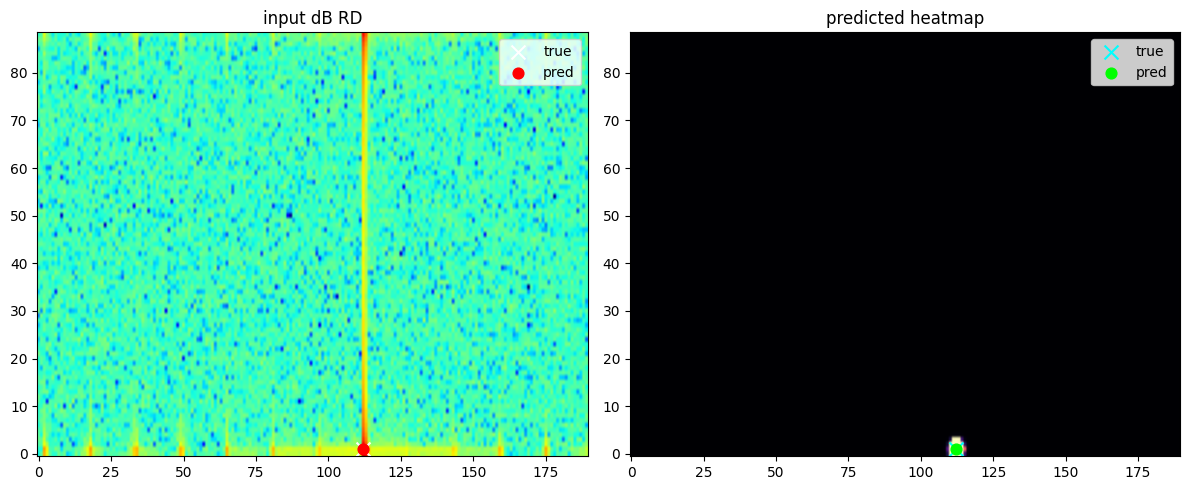

file: ./learn_dataset_vehicle_single\sample_00220.npz
used_angle: 1.79
true : (1, 110)
pred : (1, 110)
conf : 0.9999961853027344
hit  : True


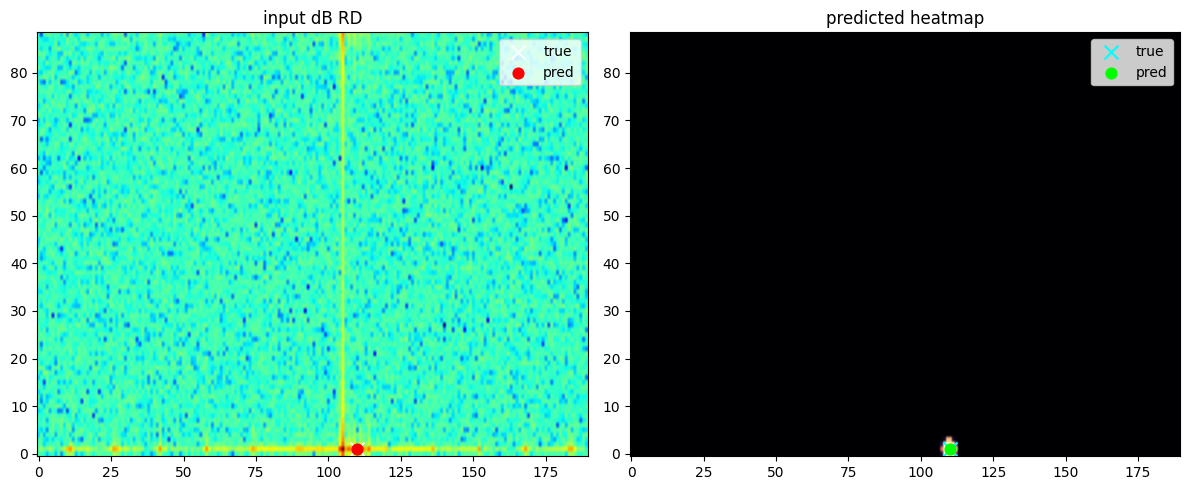

In [ ]:
def show_prediction(meta_df, sample_idx=0):
    row = meta_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    rd_complex, used_angle = load_best_angle_rd(npz_path, row["true_angle_deg"])
    x = rd_to_input(rd_complex)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        logits = best_model(x_tensor)

    pred_d, pred_r, conf = decode_peak_from_logits(logits.cpu())
    heatmap = torch.sigmoid(logits)[0, 0].cpu().numpy()
    rd_db = x[0]

    true_d = int(row["true_d_idx"])
    true_r = int(row["true_r_idx"])

    print("file:", row["file"])
    print("used_angle:", used_angle)
    print("true :", (true_d, true_r))
    print("pred :", (pred_d, pred_r))
    print("conf :", conf)
    print("hit  :", compute_hit(pred_d, pred_r, true_d, true_r))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet")
    axes[0].scatter([true_r], [true_d], c="blue", marker="x", s=100, label="true")
    axes[0].scatter([pred_r], [pred_d], c="red", marker="o", s=60, label="pred")
    axes[0].set_title("input dB RD")
    axes[0].legend()

    axes[1].imshow(heatmap, aspect="auto", origin="lower", cmap="magma")
    axes[1].scatter([true_r], [true_d], c="cyan", marker="x", s=100, label="true")
    axes[1].scatter([pred_r], [pred_d], c="lime", marker="o", s=60, label="pred")
    axes[1].set_title("predicted heatmap")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

show_prediction(ped_test_df, sample_idx=0)
show_prediction(vehicle_test_df, sample_idx=0)

In [34]:
def show_prediction(meta_df, sample_idx=0):
    row = meta_df.iloc[sample_idx]
    npz_path = row["file"]
    if not os.path.isabs(npz_path):
        npz_path = os.path.normpath(os.path.join(".", npz_path))

    rd_complex, used_angle = load_best_angle_rd(npz_path, row["true_angle_deg"])
    x = rd_to_input(rd_complex)
    x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

    H, W = rd_complex.shape
    true_d = int(row["true_d_idx"])
    true_r = int(row["true_r_idx"])
    true_heatmap = make_gaussian_heatmap(
        H, W, true_d, true_r, sigma_d=1.5, sigma_r=2.0
    )

    with torch.no_grad():
        logits = best_model(x_tensor)

    pred_d, pred_r, conf = decode_peak_from_logits(logits.cpu())
    pred_heatmap = torch.sigmoid(logits)[0, 0].cpu().numpy()
    rd_db = x[0]

    d_err = pred_d - true_d
    r_err = pred_r - true_r
    hit = compute_hit(pred_d, pred_r, true_d, true_r)

    print("target_kind:", row["target_kind"])
    print("file       :", row["file"])
    print("used_angle :", used_angle)
    print("true       :", (true_d, true_r))
    print("pred       :", (pred_d, pred_r))
    print("d_err/r_err:", (d_err, r_err))
    print("conf       :", conf)
    print("hit        :", hit)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(rd_db, aspect="auto", origin="lower", cmap="jet")
    axes[0].scatter([true_r], [true_d], c="white", marker="x", s=100, label="true")
    axes[0].scatter([pred_r], [pred_d], c="red", marker="o", s=60, label="pred")
    axes[0].set_title(f"input RD ({row['target_kind']})")
    axes[0].set_xlabel("range bin")
    axes[0].set_ylabel("doppler bin")
    axes[0].legend()

    axes[1].imshow(true_heatmap, aspect="auto", origin="lower", cmap="magma")
    axes[1].scatter([true_r], [true_d], c="cyan", marker="x", s=100, label="true")
    axes[1].set_title("target heatmap")
    axes[1].set_xlabel("range bin")
    axes[1].set_ylabel("doppler bin")
    axes[1].legend()

    axes[2].imshow(pred_heatmap, aspect="auto", origin="lower", cmap="magma")
    axes[2].scatter([true_r], [true_d], c="cyan", marker="x", s=100, label="true")
    axes[2].scatter([pred_r], [pred_d], c="lime", marker="o", s=60, label="pred")
    axes[2].set_title(f"pred heatmap  hit={hit}  conf={conf:.4f}")
    axes[2].set_xlabel("range bin")
    axes[2].set_ylabel("doppler bin")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    return {
        "target_kind": row["target_kind"],
        "file": row["file"],
        "true_d": true_d,
        "true_r": true_r,
        "pred_d": pred_d,
        "pred_r": pred_r,
        "d_err": d_err,
        "r_err": r_err,
        "conf": conf,
        "hit": hit,
    }

In [35]:
def collect_predictions(meta_df):
    rows = []

    for i in range(len(meta_df)):
        row = meta_df.iloc[i]
        npz_path = row["file"]
        if not os.path.isabs(npz_path):
            npz_path = os.path.normpath(os.path.join(".", npz_path))

        rd_complex, used_angle = load_best_angle_rd(npz_path, row["true_angle_deg"])
        x = rd_to_input(rd_complex)
        x_tensor = torch.from_numpy(x).unsqueeze(0).float().to(DEVICE)

        with torch.no_grad():
            logits = best_model(x_tensor)

        pred_d, pred_r, conf = decode_peak_from_logits(logits.cpu())
        true_d = int(row["true_d_idx"])
        true_r = int(row["true_r_idx"])
        hit = compute_hit(pred_d, pred_r, true_d, true_r)

        rows.append({
            "sample_idx": i,
            "target_kind": row["target_kind"],
            "file": row["file"],
            "true_d": true_d,
            "true_r": true_r,
            "pred_d": pred_d,
            "pred_r": pred_r,
            "d_err": pred_d - true_d,
            "r_err": pred_r - true_r,
            "conf": conf,
            "hit": hit,
        })

    return pd.DataFrame(rows)

In [36]:
pred_df = collect_predictions(test_df)

display(pred_df.groupby("target_kind")["hit"].mean())

# 失敗例
display(pred_df[pred_df["hit"] == False].head())

# 低信頼例
display(pred_df.sort_values("conf").head())

target_kind
ped        1.0
vehicle    1.0
Name: hit, dtype: float64

,sample_idx,target_kind,file,true_d,true_r,pred_d,pred_r,d_err,r_err,conf,hit


,sample_idx,target_kind,file,true_d,true_r,pred_d,pred_r,d_err,r_err,conf,hit
148,148,vehicle,./learn_dataset_vehicle_single\sample_00288.npz,1,92,1,95,0,3,0.999993,True
130,130,vehicle,./learn_dataset_vehicle_single\sample_00270.npz,1,97,1,96,0,-1,0.999993,True
142,142,vehicle,./learn_dataset_vehicle_single\sample_00282.npz,1,94,1,93,0,-1,0.999994,True
112,112,vehicle,./learn_dataset_vehicle_single\sample_00252.npz,1,102,1,101,0,-1,0.999994,True
134,134,vehicle,./learn_dataset_vehicle_single\sample_00274.npz,1,96,1,96,0,0,0.999995,True


In [37]:
pred_df["exact_match"] = (
    (pred_df["pred_d"] == pred_df["true_d"]) &
    (pred_df["pred_r"] == pred_df["true_r"])
)
display(pred_df.groupby("target_kind")["exact_match"].mean())
display(
    pred_df.groupby("target_kind")[["d_err", "r_err"]].agg(["mean", "std", "max", "min"])
)
display(test_df.groupby("target_kind")[["true_d_idx", "true_r_idx"]].describe())
display(pred_df[pred_df["target_kind"] == "ped"].query("r_err != 0").head(10))
display(pred_df[pred_df["target_kind"] == "vehicle"].query("r_err != 0").head(10))

target_kind
ped        0.75
vehicle    0.60
Name: exact_match, dtype: float64

d_err                r_err                  
             mean  std max min    mean       std max min
target_kind                                             
ped           0.0  0.0   0   0 -0.2500  0.435745   0  -1
vehicle       0.0  0.0   0   0 -0.1125  0.899982   3  -1

true_d_idx                                    true_r_idx  \
                 count mean  std  min  25%  50%  75%  max      count   
target_kind                                                            
ped               80.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0       80.0   
vehicle           80.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0       80.0   

                                                                   
                 mean       std   min    25%    50%    75%    max  
target_kind                                                        
ped          101.8250  5.963550  92.0  97.00  102.0  107.0  112.0  
vehicle       99.7375  5.988901  90.0  94.75  100.0  105.0  110.0

,sample_idx,target_kind,file,true_d,true_r,pred_d,pred_r,d_err,r_err,conf,hit,exact_match
5,5,ped,./learn_dataset_ped_single\sample_00225.npz,1,111,1,110,0,-1,1.000000,True,False
9,9,ped,./learn_dataset_ped_single\sample_00229.npz,1,110,1,109,0,-1,0.999999,True,False
13,13,ped,./learn_dataset_ped_single\sample_00233.npz,1,109,1,108,0,-1,0.999999,True,False
17,17,ped,./learn_dataset_ped_single\sample_00237.npz,1,108,1,107,0,-1,1.000000,True,False
21,21,ped,./learn_dataset_ped_single\sample_00241.npz,1,107,1,106,0,-1,1.000000,True,False
25,25,ped,./learn_dataset_ped_single\sample_00245.npz,1,106,1,105,0,-1,1.000000,True,False
28,28,ped,./learn_dataset_ped_single\sample_00248.npz,1,105,1,104,0,-1,1.000000,True,False
29,29,ped,./learn_dataset_ped_single\sample_00249.npz,1,105,1,104,0,-1,1.000000,True,False
32,32,ped,./learn_dataset_ped_single\sample_00252.npz,1,104,1,103,0,-1,1.000000,True,False
36,36,ped,./learn_dataset_ped_single\sample_00256.npz,1,103,1,102,0,-1,1.000000,True,False


,sample_idx,target_kind,file,true_d,true_r,pred_d,pred_r,d_err,r_err,conf,hit,exact_match
81,81,vehicle,./learn_dataset_vehicle_single\sample_00221.npz,1,110,1,109,0,-1,0.999999,True,False
85,85,vehicle,./learn_dataset_vehicle_single\sample_00225.npz,1,109,1,108,0,-1,1.000000,True,False
89,89,vehicle,./learn_dataset_vehicle_single\sample_00229.npz,1,108,1,107,0,-1,0.999999,True,False
93,93,vehicle,./learn_dataset_vehicle_single\sample_00233.npz,1,107,1,106,0,-1,1.000000,True,False
96,96,vehicle,./learn_dataset_vehicle_single\sample_00236.npz,1,106,1,105,0,-1,0.999999,True,False
97,97,vehicle,./learn_dataset_vehicle_single\sample_00237.npz,1,106,1,105,0,-1,0.999999,True,False
110,110,vehicle,./learn_dataset_vehicle_single\sample_00250.npz,1,102,1,101,0,-1,1.000000,True,False
111,111,vehicle,./learn_dataset_vehicle_single\sample_00251.npz,1,102,1,101,0,-1,0.999999,True,False
112,112,vehicle,./learn_dataset_vehicle_single\sample_00252.npz,1,102,1,101,0,-1,0.999994,True,False
114,114,vehicle,./learn_dataset_vehicle_single\sample_00254.npz,1,101,1,100,0,-1,0.999999,True,False
